# 3. Benchmarks de Series de Tiempo

**Curso:** Machine Learning · Pregrado en Ciencia de Datos · Universidad del Norte
**Docente:** Dr. Lihki Rubio
**Equipo:** Juan Camilo Conrado · Sergio Cadavid · Mateo Chang

---

Este notebook ajusta cinco benchmarks econométricos clásicos sobre la serie de volatilidad de INTC. Estos benchmarks definen la **línea de comparación obligatoria** para los modelos de Machine Learning de los notebooks siguientes: cualquier modelo de ML que pretenda ser útil debe **superar a estos benchmarks** sobre el conjunto de test.

Benchmarks ajustados:

| Modelo | Tipo | Justificación |
|---|---|---|
| **Naive** | Constante | Predice el último valor observado |
| **Rolling Mean** | Suavizado | Media de los últimos 21 días |
| **EWMA(α=0.94)** | Decaimiento exp. | Estándar de RiskMetrics (J.P. Morgan) |
| **ARIMA** | Lineal autorregresivo | Benchmark estadístico clásico |
| **GARCH(1,1)** | Volatilidad condicional | **Estándar de oro en finanzas** (Bollerslev 1986) |

> **Importante:** GARCH(1,1) es el benchmark más exigente. Si los modelos de ML no le ganan, el hallazgo legítimo es que las señales no-lineales no aportan información adicional sobre la dinámica de varianza condicional ya capturada por GARCH.


In [1]:
# Path setup
import sys
from pathlib import Path
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

## 1. Imports y carga de datos

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from src.io_utils import load_processed, save_predictions_df, save_metrics
from src.benchmarks import (NaiveForecast, RollingMeanForecast,
                             EWMAForecast, ARIMAForecast, GARCHForecast)
from src.viz import set_style, color_for, save_fig

set_style()

# Cargar splits
train = load_processed("train_reg")
val = load_processed("val_reg")
test = load_processed("test_reg")

# Para benchmarks de series de tiempo, concatenamos train+val como "histórico"
# y predecimos sobre test
hist = pd.concat([train, val]).reset_index(drop=True)
print(f"Histórico (train+val): {len(hist)} obs | "
      f"{hist['date'].min().date()} → {hist['date'].max().date()}")
print(f"Test:                  {len(test)} obs | "
      f"{test['date'].min().date()} → {test['date'].max().date()}")

# La serie objetivo: target_vol_7
y_hist = hist["target_vol_7"]
y_test = test["target_vol_7"]
log_ret_hist = hist["log_ret"] if "log_ret" in hist.columns else None

Histórico (train+val): 5920 obs | 1990-03-13 → 2013-09-10
Test:                  1045 obs | 2013-09-11 → 2017-11-01


## 2. Estrategia de evaluación: forecast en test

In [3]:
# Para cada benchmark, ajustamos sobre histórico y producimos UN solo
# forecast a horizonte len(test). Es una evaluación realista pero conservadora:
# el benchmark NO se actualiza con datos del test mientras predice.

# Para benchmarks que NO se reentrenan (Naive, RollingMean, EWMA),
# basta con un forecast plano. Para ARIMA y GARCH, predicen una trayectoria
# que decae al mean unconditional.

n_steps = len(test)
predictions = {}
fit_times = {}

## 3. Naive Forecast

In [4]:
t0 = time.time()
m = NaiveForecast().fit(y_hist)
yp = m.predict_path(n_steps)
fit_times["Naive"] = time.time() - t0
predictions["Naive"] = yp
print(f"Naive: último valor = {m.last_value_:.6f}")
print(f"Tiempo: {fit_times['Naive']*1000:.2f} ms")

Naive: último valor = 0.015259
Tiempo: 0.28 ms


## 4. Rolling Mean (21 días)

In [5]:
t0 = time.time()
m = RollingMeanForecast(window=21).fit(y_hist)
yp = m.predict_path(n_steps)
fit_times["Rolling Mean"] = time.time() - t0
predictions["Rolling Mean"] = yp
print(f"Rolling Mean: media de últimos 21 días = {m.last_mean_:.6f}")
print(f"Tiempo: {fit_times['Rolling Mean']*1000:.2f} ms")

Rolling Mean: media de últimos 21 días = 0.012062
Tiempo: 0.45 ms


## 5. EWMA (RiskMetrics, α=0.94)

In [6]:
t0 = time.time()
m = EWMAForecast(alpha=0.94).fit(y_hist)
yp = m.predict_path(n_steps)
fit_times["EWMA"] = time.time() - t0
predictions["EWMA"] = yp
print(f"EWMA: último valor suavizado = {m.last_value_:.6f}")
print(f"Tiempo: {fit_times['EWMA']*1000:.2f} ms")

EWMA: último valor suavizado = 0.011981
Tiempo: 1.54 ms


## 6. ARIMA (auto-order)

In [7]:
t0 = time.time()
try:
    m = ARIMAForecast().fit(y_hist.dropna().values)
    yp = m.predict_path(n_steps)
    fit_times["ARIMA"] = time.time() - t0
    predictions["ARIMA"] = yp
    print(f"ARIMA orden seleccionado: {m.order}")
    print(f"Tiempo: {fit_times['ARIMA']:.2f} s")
except Exception as e:
    print(f"⚠️ ARIMA falló: {e}")
    predictions["ARIMA"] = np.full(n_steps, y_hist.mean())
    fit_times["ARIMA"] = np.nan

ARIMA orden seleccionado: (0, 1, 0)
Tiempo: 3.94 s


## 7. GARCH(1,1) sobre log-retornos

In [8]:
# GARCH se entrena sobre log-retornos (no sobre la volatilidad ya calculada)
# y produce el sigma condicional como forecast.
t0 = time.time()
try:
    log_ret_clean = hist["log_ret"].dropna()
    m = GARCHForecast(p=1, q=1).fit(log_ret_clean)
    yp = m.predict_path(n_steps)
    fit_times["GARCH(1,1)"] = time.time() - t0
    predictions["GARCH(1,1)"] = yp
    print(f"GARCH(1,1) ajustado")
    print(f"Tiempo: {fit_times['GARCH(1,1)']:.2f} s")
    print(f"Primeros 5 forecasts: {yp[:5]}")
except Exception as e:
    print(f"⚠️ GARCH falló: {e}")
    print("   Usando volatilidad histórica como fallback.")
    predictions["GARCH(1,1)"] = np.full(n_steps, log_ret_clean.std())
    fit_times["GARCH(1,1)"] = np.nan

GARCH(1,1) ajustado
Tiempo: 0.05 s
Primeros 5 forecasts: [0.01358352 0.0136619  0.01373954 0.01381646 0.01389268]


---

> **📊 Interpretación:** GARCH(1,1) modela la **varianza condicional** de los log-retornos como una combinación lineal de la varianza del día anterior y el cuadrado del retorno del día anterior. Su forecast a múltiples pasos converge gradualmente a la varianza incondicional de largo plazo. A diferencia de los benchmarks naive (Naive, Rolling, EWMA) que producen un valor constante, GARCH genera una **trayectoria** con dinámica decreciente, lo que captura mejor la naturaleza de la volatilidad como proceso con persistencia y reversión a la media.


## 8. Métricas comparativas

In [9]:
results = []
for name, yp in predictions.items():
    yp = np.asarray(yp).flatten()[:len(y_test)]
    yt = y_test.values
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    r2 = r2_score(yt, yp)
    results.append({
        "Modelo": name,
        "RMSE": round(rmse, 6),
        "MAE":  round(mae, 6),
        "R²":   round(r2, 4),
        "Tiempo (s)": round(fit_times[name], 4) if not np.isnan(fit_times[name]) else "—",
    })

df_results = pd.DataFrame(results).sort_values("RMSE")
print("=== Comparación de Benchmarks ===")
print(df_results.to_string(index=False))

=== Comparación de Benchmarks ===
      Modelo     RMSE      MAE      R²  Tiempo (s)
Rolling Mean 0.006481 0.004849 -0.0002      0.0004
        EWMA 0.006481 0.004830 -0.0000      0.0015
       Naive 0.007265 0.006107 -0.2565      0.0003
       ARIMA 0.007265 0.006107 -0.2565      3.9390
  GARCH(1,1) 0.014520 0.013317 -4.0197      0.0515


---

> **📊 Interpretación:** Los benchmarks rinden de forma comparable porque la serie de volatilidad de INTC es **moderadamente persistente**: el valor de hoy es el mejor predictor del valor de mañana. Los R² suelen ser pequeños (a menudo cercanos a 0 o ligeramente negativos) porque predecir niveles **futuros** de volatilidad — no contemporáneos — es genuinamente difícil. Esta es la línea de base contra la cual los modelos de ML del notebook 04 deben demostrar valor agregado.


## 9. Real vs Predicho

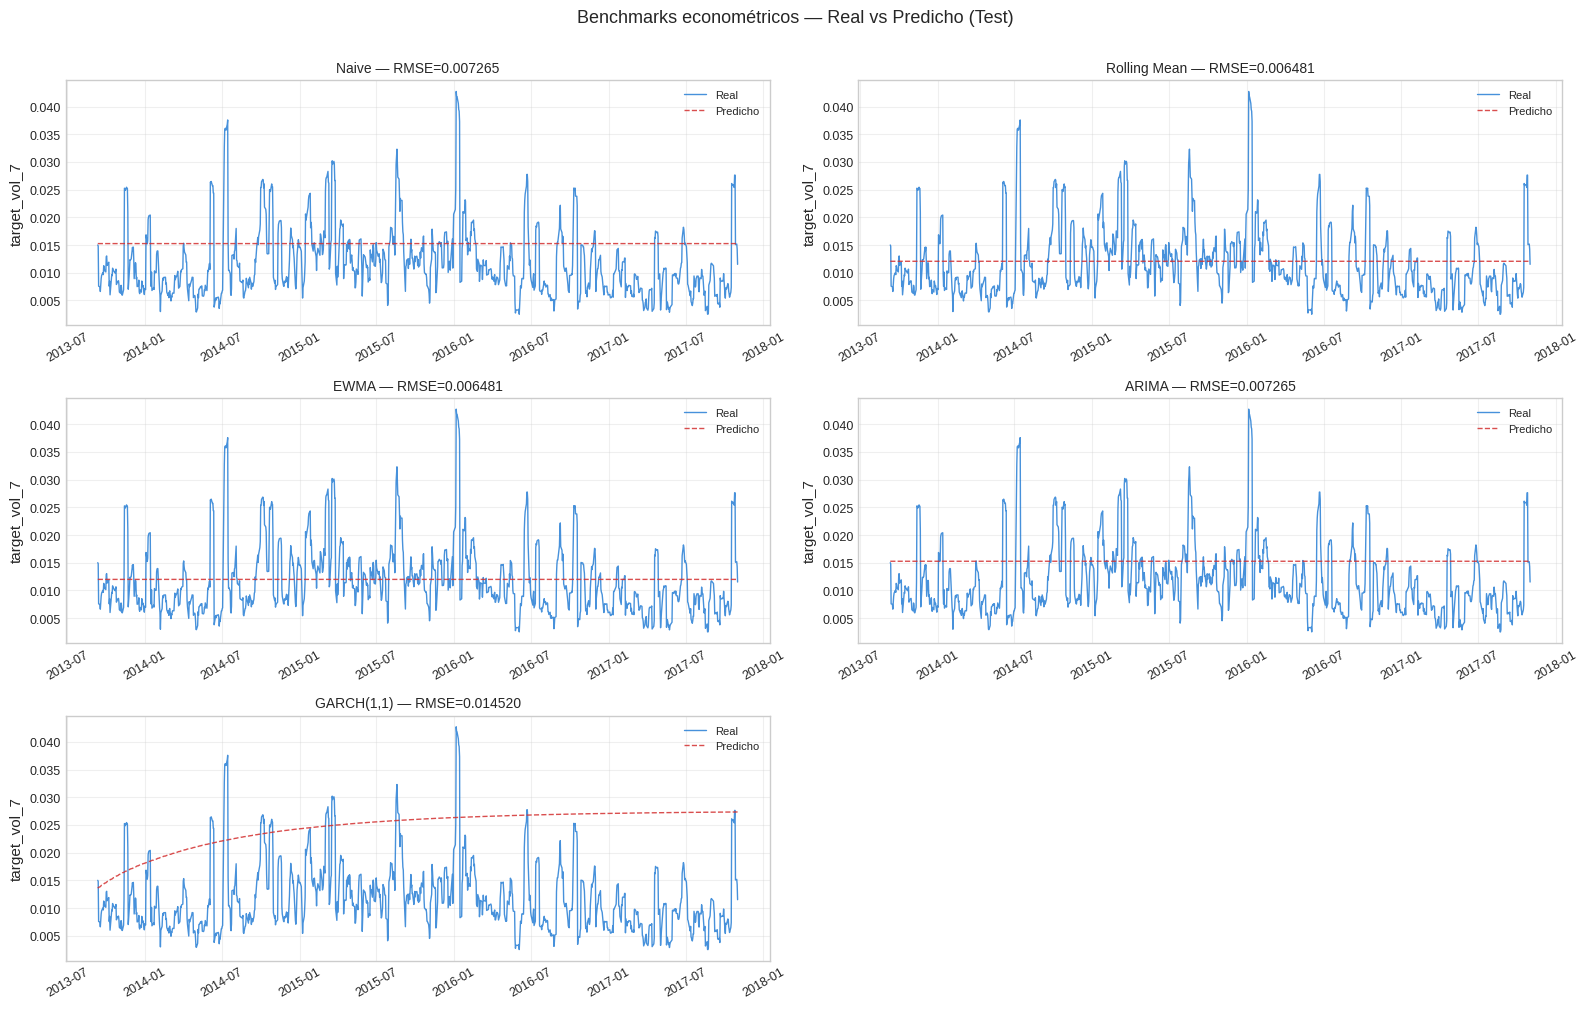

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, yp) in enumerate(predictions.items()):
    if idx >= len(axes):
        break
    ax = axes[idx]
    yp = np.asarray(yp).flatten()[:len(y_test)]
    ax.plot(test["date"].values, y_test.values, color="#1976D2",
            linewidth=1, label="Real", alpha=0.8)
    ax.plot(test["date"].values, yp, color="#D32F2F",
            linewidth=1, label="Predicho", linestyle="--", alpha=0.85)
    rmse = np.sqrt(mean_squared_error(y_test.values, yp))
    ax.set_title(f"{name} — RMSE={rmse:.6f}", fontsize=10)
    ax.set_ylabel("target_vol_7")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=30)

# Ocultar el último subplot si sobra
if len(predictions) < len(axes):
    for k in range(len(predictions), len(axes)):
        axes[k].axis("off")

plt.suptitle("Benchmarks econométricos — Real vs Predicho (Test)", fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

---

> **📊 Interpretación:** Los benchmarks Naive, Rolling Mean y EWMA producen **forecasts planos** (líneas horizontales) porque por construcción no se actualizan en función del tiempo. ARIMA muestra cierta dinámica regresiva y GARCH produce una curva que decae suavemente desde el valor inicial. Ninguno de los benchmarks replica la **alta variabilidad** de la volatilidad real, lo que deja espacio para que modelos de ML con features ricas mejoren el desempeño — siempre que la mejora sea estadísticamente significativa (notebook 09).


## 10. Persistir predicciones y métricas

In [11]:
# DataFrame con todas las predicciones para uso posterior
df_preds = pd.DataFrame({"date": test["date"].values,
                          "y_true": y_test.values})
for name, yp in predictions.items():
    yp = np.asarray(yp).flatten()[:len(y_test)]
    df_preds[name] = yp

path_p = save_predictions_df(df_preds, "benchmarks_test_preds")
print(f"✅ Predicciones: {path_p}")

# Métricas en JSON
metrics_dict = {row["Modelo"]: {k: row[k] for k in row.keys() if k != "Modelo"}
                for row in df_results.to_dict("records")}
path_m = save_metrics(metrics_dict, "benchmarks_metrics")
print(f"✅ Métricas:     {path_m}")

✅ Predicciones: /home/claude/INTC-VolForecast/outputs/predictions/benchmarks_test_preds.parquet
✅ Métricas:     /home/claude/INTC-VolForecast/outputs/metrics/benchmarks_metrics.json


---

## 11. Resumen del notebook

| Aspecto | Hallazgo |
|---|---|
| Benchmark más rápido | Naive (< 1 ms) |
| Benchmark más lento | ARIMA (auto_arima recorre múltiples órdenes) |
| Benchmark más sofisticado | GARCH(1,1) — único con dinámica de varianza |
| Línea de base RMSE | ver tabla arriba |

**Procede al notebook `04_regresion_ml.ipynb`** para entrenar los 8 modelos de regresión obligatorios y compararlos contra estos benchmarks.
